<a href="https://colab.research.google.com/github/Adharsh96/PulseBI-AI_Analytical_tool/blob/master/PulseBI_AI_Analytical_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PulseBI AI Analytical Tool**

Required libraries

***pandas*** for data handling
***numpy*** for numerical operations

**matplotlib** for charts and visualisation

**ydata-profiling** for automatic data analysis report

***tabulate*** for pretty table

In [ ]:
!pip install pandas numpy matplotlib ydata-profiling tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00


**Libraries**

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Auto EDA Report
from ydata_profiling import ProfileReport

# File upload
from google.colab import files

# Better notebook display
from tabulate import tabulate

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


/tmp/ipykernel_2285/1396996757.py:10: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


**Upload Dataset**

In [ ]:
# This opens file upload dialog in Google Colab
uploaded = files.upload()

# Get uploaded filename
file_name = list(uploaded.keys())[0]

print(f"✅ Uploaded File: {file_name}")

Saving super_store.csv to super_store (1).csv
✅ Uploaded File: super_store (1).csv


**Load Dataset**

In [ ]:
# Read CSV file into pandas dataframe
df = pd.read_csv(file_name, encoding='latin1')

# Display first 5 rows
print("\n✅ FIRST 5 ROWS OF DATASET\n")

print(tabulate(df.head(), headers='keys', tablefmt='pretty'))


✅ FIRST 5 ROWS OF DATASET

+---+--------+----------------+------------+------------+----------------+-------------+-----------------+-----------+---------------+-----------------+------------+-------------+--------+-----------------+-----------------+--------------+-------------------------------------------------------------+----------+----------+----------+----------+
|   | Row ID |    Order ID    | Order Date | Ship Date  |   Ship Mode    | Customer ID |  Customer Name  |  Segment  |    Country    |      City       |   State    | Postal Code | Region |   Product ID    |    Category     | Sub-Category |                        Product Name                         |  Sales   | Quantity | Discount |  Profit  |
+---+--------+----------------+------------+------------+----------------+-------------+-----------------+-----------+---------------+-----------------+------------+-------------+--------+-----------------+-----------------+--------------+-----------------------------------------

**Dataset Overview**

In [ ]:
print("\n================ DATASET INFORMATION ================\n")

# Shape of dataset
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# Column names
print("\nCOLUMN NAMES:\n")
print(df.columns.tolist())

# Data types
print("\nDATA TYPES:\n")
print(df.dtypes)

# Missing values
print("\nMISSING VALUES:\n")
print(df.isnull().sum())


================ DATASET INFORMATION ================

Rows    : 9994
Columns : 21

COLUMN NAMES:

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

DATA TYPES:

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

MISSING VALUES:

Row ID           0
Order ID         0
Order Date       0
Ship Date   

Basic Data Cleaning

In [ ]:
print("Before Cleaning Shape:", df.shape)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing numerical values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("After Cleaning Shape:", df.shape)

print("\n✅ Data cleaning completed")

Before Cleaning Shape: (9994, 21)
After Cleaning Shape: (9994, 21)

✅ Data cleaning completed


**Generate Automatic AI Report**

In [ ]:
print("Generating AI Report...")
print("This may take 1-2 minutes depending on dataset size")

# Create profiling report
profile = ProfileReport(
    df,
    title="PulseBI AI Report",
    explorative=True
)

# Save report
profile.to_file("PulseBI_AI_Report.html")

print("\n✅ AI Report Generated Successfully")
print("📄 File Name: PulseBI_AI_Report.html")

Generating AI Report...
This may take 1-2 minutes depending on dataset size


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:01<00:00, 16.50it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


✅ AI Report Generated Successfully
📄 File Name: PulseBI_AI_Report.html


In [ ]:
# DOWNLOAD GENERATED REPORT

files.download("PulseBI_AI_Report.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Visualization**

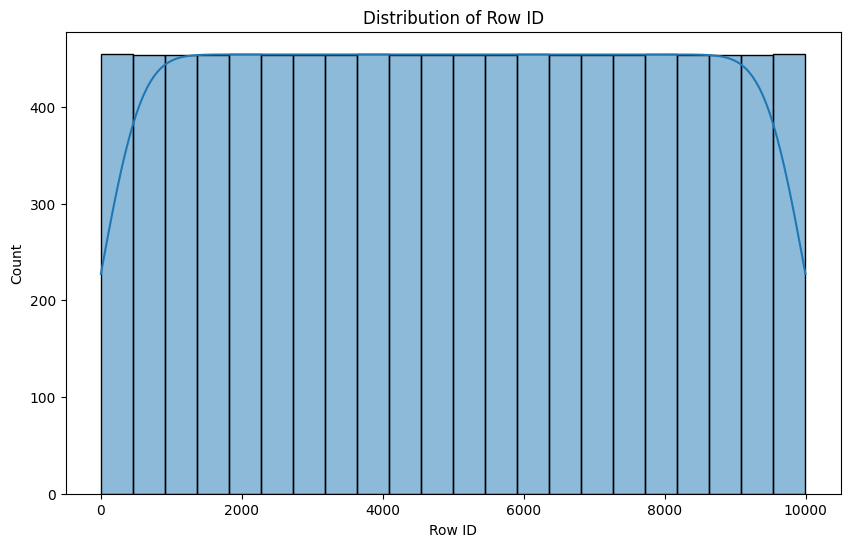

In [ ]:
# Set chart size
plt.figure(figsize=(10,6))

# Select first numerical column
numeric_cols = df.select_dtypes(include=np.number).columns

# Histogram
sns.histplot(df[numeric_cols[0]], kde=True)

plt.title(f"Distribution of {numeric_cols[0]}")
plt.xlabel(numeric_cols[0])
plt.ylabel("Count")

plt.show()

**Correlation Heatmap**

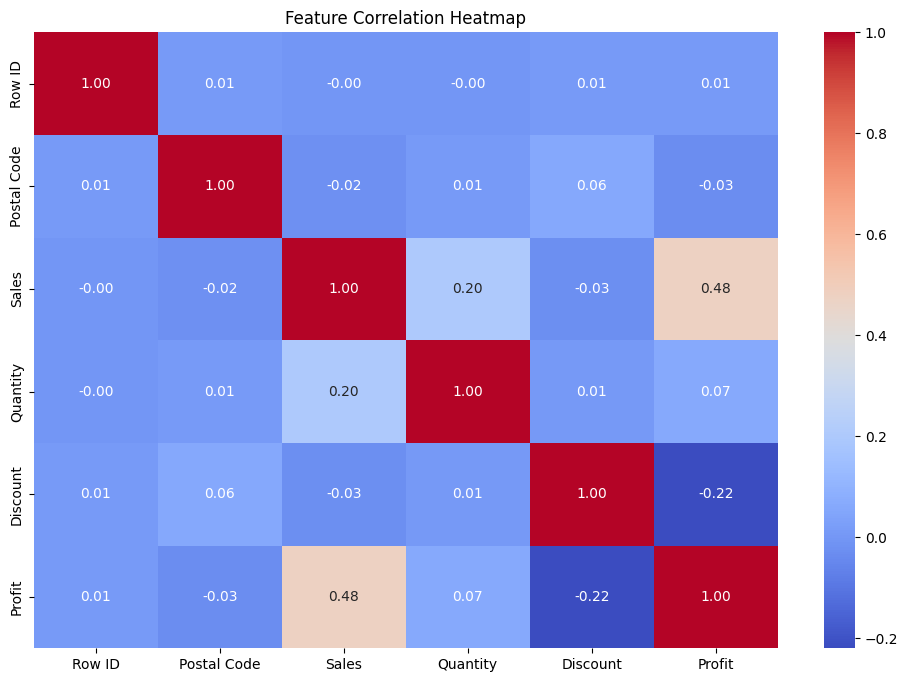

In [ ]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

**Save and download cleaned data**

In [ ]:
cleaned_file_name = "PulseBI_Cleaned_Data.csv"

# Save cleaned dataframe
df.to_csv(cleaned_file_name, index=False)

print(f"✅ Cleaned dataset saved as: {cleaned_file_name}")
#Download cleaned dataset
files.download("PulseBI_Cleaned_Data.csv")

✅ Cleaned dataset saved as: PulseBI_Cleaned_Data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000
